In [9]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

import torch 
import torch.nn as nn 
import torch.optim as optim 

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data = pd.read_csv("mnist_train.csv")
data.shape

(60000, 785)

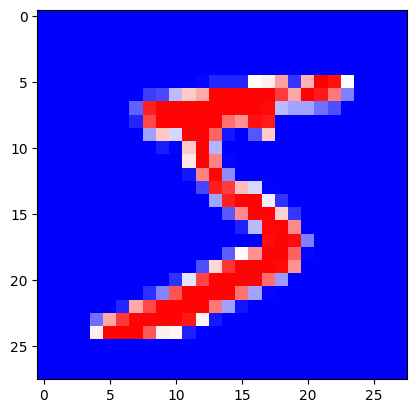

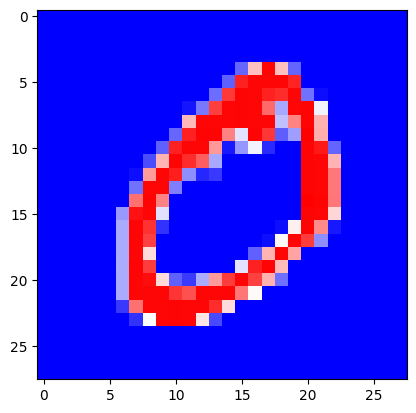

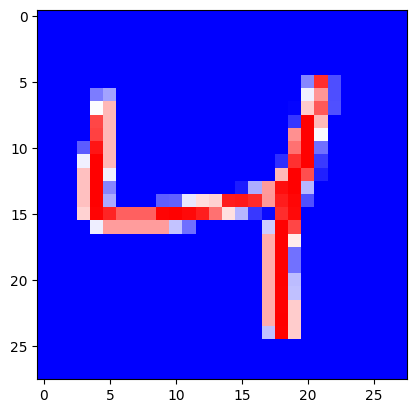

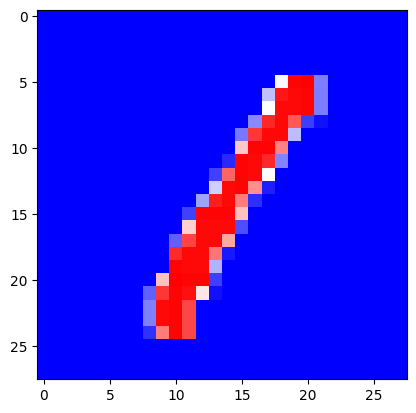

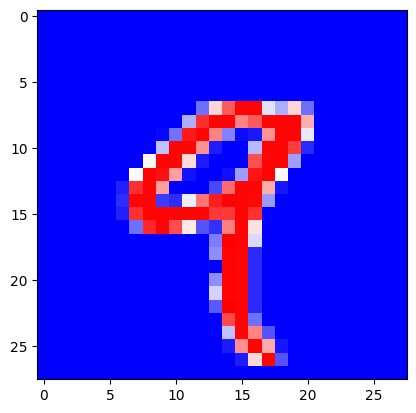

In [17]:
for i in range(5):
    feat = data.iloc[i,1:]
    feat = np.array(feat)
    feat = feat.reshape((28,28))
    plt.imshow(feat, cmap = "bwr")
    plt.show()

In [19]:
X = data.drop('label', axis = 1)
Y= data['label']

X_train, X_test, y_train,y_test = train_test_split(X, Y, test_size=0.2)

X_train = X_train/255.0
X_test = X_test / 255.0

X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [23]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X= torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self,index):
        return self.X[index], self.y[index]
    
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

    

In [ ]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=torch.cuda.is_available())




(48000, 12000)

In [49]:
class mnistNN(nn.Module):
    def __init__(self,n_features = 784, n_classes =10):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(n_features,512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(), 

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,10)
           
        )

    def forward(self, X):
        return self.model(X)


In [50]:
model = mnistNN(X_train.shape[1], 10)
model = model.to(device)

model

mnistNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=10, bias=True)
  )
)

In [51]:
lr = 3e-4
n_epochs = 10

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(params=model.parameters(), lr = lr)

In [62]:
for epoch in range(n_epochs):
    model.train()
    total_epoch_loss = 0
    train_losses = []
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        y_pred = model(batch_X)
        loss = loss_fn(y_pred,batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()

    average_epoch_loss= total_epoch_loss/ len(train_loader)
    train_losses.append(average_epoch_loss)
    print(f"Epoch : [{epoch + 1 } / {n_epochs}] : {average_epoch_loss:.10f}")

Epoch : [1 / 10] : 0.0051078715
Epoch : [2 / 10] : 0.0049073245
Epoch : [3 / 10] : 0.0044046605
Epoch : [4 / 10] : 0.0023860188
Epoch : [5 / 10] : 0.0076063062
Epoch : [6 / 10] : 0.0038275285
Epoch : [7 / 10] : 0.0053515026
Epoch : [8 / 10] : 0.0046230085
Epoch : [9 / 10] : 0.0027296353
Epoch : [10 / 10] : 0.0047747187


In [63]:
total_labels = len(test_dataset)
correct_predictions = 0

model.eval()

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        y_pred = model(batch_X)
        pred_label = torch.argmax(y_pred, dim=1)
        batch_correct_preds = (batch_y == pred_label).sum().item()
        correct_predictions+= batch_correct_preds

acc = correct_predictions/ total_labels

print(f"the accuracy  = {acc*100:.10f}")

the accuracy  = 97.7916666667


11732